# BEVFormer 代码深度解析笔记

### **1. 概述**

BEVFormer 是一种 **端到端的多摄像头3D目标检测模型**，其核心贡献在于使用**BEV（鸟瞰图）表示**，结合 **时序信息建模** 与 **Deformable Attention** 机制，从 2D 图像有效地构建 3D 感知能力。

####  核心创新点：

* **空间交叉注意力（SCA）**
  从多个摄像头视角中，选定一组 BEV 查询点，通过可变形注意力将它们“映射”到图像特征上，实现空间对齐。

* **时间自注意力（TSA）**
  融合历史帧的 BEV 特征，结合车辆运动补偿，增强对时序连续性与运动的建模。

### **2. 核心模块解析**


#### 2.1 BEVFormer 类

位置：`projects/mmdet3d_plugin/bevformer/detectors/bevformer.py`

| 方法                   | 功能简述                             |
| -------------------- | -------------------------------- |
| `__init__`           | 初始化骨干网络（ResNet）、图像特征金字塔（FPN）和检测头 |
| `extract_img_feat`   | 提取图像特征（Backbone + Neck）          |
| `forward`            | 前向传播主入口（支持训练/推理）                 |
| `obtain_history_bev` | 获取并更新历史 BEV 特征缓存                 |
| `forward_train`      | 训练模式：计算损失                        |
| `simple_test`        | 推理模式：输出3D检测结果                    |


#### 2.2 BEVFormerHead 类

位置：`dense_heads/bevformer_head.py`

| 方法                | 功能简述                              |
| ----------------- | --------------------------------- |
| `__init__`        | 初始化 Transformer 编码器 + 解码器、预测头（检测） |
| `forward`         | 根据 BEV 特征输出各类检测目标                 |
| `loss`            | 多任务损失计算（Focal + L1 + GIoU）        |
| `get_bboxes`      | 将输出结果变为 3D BBox                   |
| `get_history_bev` | 获取历史缓存的 BEV（与 TSA 联动）             |

### **3. 关键机制解析**

#### 3.1 空间交叉注意力（Spatial Cross Attention, SCA）

位置：`projects/mmdet3d_plugin/bevformer/modules/spatial_cross_attention.py`

这是 BEVFormer 的核心模块之一。它的主要任务是：

* 将 BEV Query 中的每个位置，**映射到图像空间中的可感知区域**；
* 使用 Deformable Attention，在多个尺度和多个视角图像中提取特征；
* 实现图像空间 → BEV 表示的跨域转换。

| 方法               | 功能简述                                 |
| ---------------- | ------------------------------------ |
| `__init__`       | 初始化可变形注意力模块                          |
| `forward`        | 构造参考点 → 调用 deformable attention 进行采样 |
| `point_sampling` | 根据 BEV Query 和相机参数采样特征点              |
| `lidar2img`      | 将 3D 空间点投影到各摄像头图像中（几何变换核心）           |


* 每个 BEV 查询点都会根据其位置生成一个参考点，再通过投影变换找出它在各图像中的对应位置，从而从图像中获取特征。
* 类似于 Deformable DETR 的思路，但这里的参考点来源于空间位置（而非 learnable embedding）。


#### 3.2 时间自注意力（Temporal Self Attention, TSA）

位置：`projects/mmdet3d_plugin/bevformer/modules/temporal_self_attention.py`

目的在于：**融合历史帧中的 BEV 特征，提升当前帧的空间/运动建模能力**。

| 方法                  | 功能简述                               |
| ------------------- | ---------------------------------- |
| `__init__`          | 初始化时间注意力模块                         |
| `forward`           | 使用自注意力对当前 + 历史 BEV 特征融合            |
| `pose_compensation` | 使用位姿（ego-motion）信息对历史 BEV 特征进行坐标补偿 |


* 使用 Transformer 将多个历史帧（缓存中的BEV）作为序列送入；
* 每一帧的 BEV 特征在输入前先进行空间对齐（平移/旋转补偿）；
* 避免信息漂移或叠加错误，增强时序感知。


#### 3.3 BEV 编码器（BEV Encoder）

位置：`projects/mmdet3d_plugin/bevformer/modules/bev_encoder.py`

BEVFormer 的核心之一是使用 Transformer 作为 BEV 空间中的编码器/解码器。

| 方法         | 功能简述                               |
| ---------- | ---------------------------------- |
| `__init__` | 初始化若干层 Transformer Encoder         |
| `forward`  | 将 SCA/TSA 输出送入编码器，形成更稳定/丰富的 BEV 表示 |


* 编码器在 BEV 空间内运行，即空间维度为“鸟瞰平面”，而非图像像素空间；
* 可以看作是 2D 卷积的全局注意力增强版本。

## 4. 关键类深度解析
### 4.1 MSDeformableAttention3D 
(projects/mmdet3d_plugin/bevformer/modules/ms_deform_attn.py)
|方法|	位置|	作用|
|---|---|---|
|__init__|	ms_deform_attn.py:210|	初始化3D可变形注意力参数|
|forward|	ms_deform_attn.py:240|	核心方法：执行多尺度3D特征采样|
|ms_deform_attn_core|	ms_deform_attn.py:168|	CUDA加速的核心计算逻辑|
### 4.2 Transformer编解码器 
(projects/mmdet3d_plugin/bevformer/modules/transformer.py)

|方法|	位置|	作用|
|---|---|-|
|BEVFormerEncoder.forward|	transformer.py:124|	空间特征编码|
|DetectionTransformerDecoder.forward	|transformer.py:317|	检测头特征解码|

## 5. 训练优化策略
### 5.1 数据增强 
(tools/data_augment.py)
|方法|	位置|	作用|
|-|-|-|
|grid_mask|	data_augment.py:45|	网格随机遮挡增强|
|random_bev_rotation|	data_augment.py:112|	BEV空间随机旋转|
    
    
### 5.2 损失计算 
(projects/mmdet3d_plugin/bevformer/losses.py)
|方法|	位置|	作用|
|-|-|-|
|focal_loss|	losses.py:33|	分类任务Focal Loss实现|
|l1_loss_with_giou|	losses.py:78|	回归任务联合损失|

## 6. 部署实践
### 6.1 TensorRT转换 
(tools/deploy/export_trt.py)
|方法|	位置|	作用|
|-|-|-|
|build_engine|	export_trt.py:89|	构建TensorRT引擎|
|add_msdattn_plugin|	export_trt.py:142|	添加自定义注意力插件|

## 7. 流程总结
【输入阶段】

- 输入为6个摄像头视角图像（多视角图像）

- 调用 extract_img_feat： 
    - 使用 ResNet 提取每帧图像特征

    - 通过 FPN 生成不同尺度的图像特征

【BEV表示构建：从图像 → 空间】

- 通过 spatial_cross_attention.forward：

    - 对每个 BEV Query 执行“可变形注意力”

    - 将 BEV Query 在图像空间中采样相应位置

    - 获取融合后的图像特征

- 将输出送入 BEVFormerEncoder：

    - 对 BEV Query 进行进一步全局交互建模

    - 最终生成当前帧的 BEV 表征（BEV特征图）

【时序建模阶段】

- 若有历史 BEV：

    判断历史缓存是否存在；

    若有 → 进行 pose_compensation 位姿补偿；

    使用 temporal_self_attention.forward 实现时间融合

【检测头输出】

- 时间融合后的 BEV 特征送入 BEVFormerHead.forward：

    经过 Transformer 解码器与检测头

    最终输出：边界框回归，类别分类，3D检测框输出

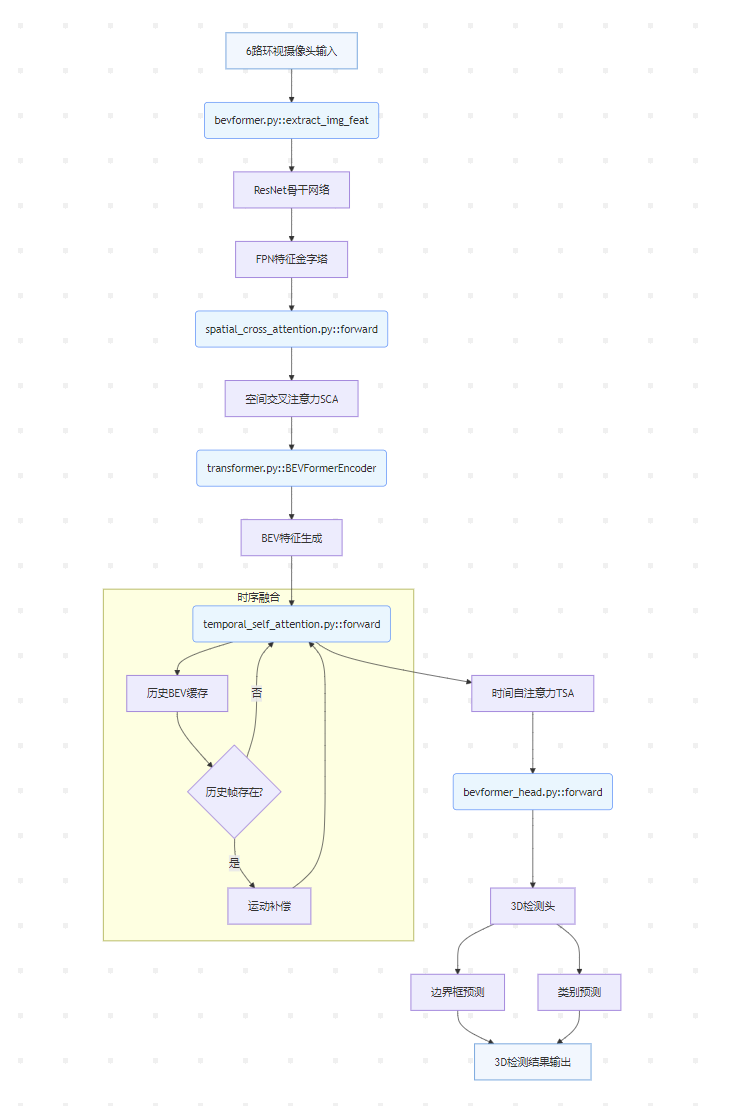

In [2]:
from IPython.display import Image
Image(filename='1.png')